# CMSE 201 Final Project

### Ty Siemens
### Section_008
#### December 2, 2024

# NCAA 2023-24 BETTING ODDS

## Background and Motivation

In 2023, sports bettors spend apporximately 120 BILLION dollars on sports betting resulting in an 11 billion dollar profit for the industry. For such a large business, getting the numbers correct is crucial to maintaining a profit in an industry set on it's consumers making money. As a result, I was interested in seeing how accurate are betting lines? Line providers are set with predicting how they believe a sports game will end, so that their consumers can bet on many aspects of the game including the 2 most popular: The "spread", where the company give a number for how much they think one team will win by and consumers bet on whether team will 'cover the spread' and outscore or underscore their projection, and the "over under" where the company gives a number for what they calculate to be the combined score of both teams and the consumers bets on whether the combined score is over or under this mark. Therefore, my question is:

## **How accurate were football betting odds from the 2023 NCAA season, and which company (if any) produces the most accurate result?**

## Methodology

In [168]:
# import functions

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from scipy.stats import norm

In [170]:
# import our data frame

oddsdata = pd.read_csv('bettingodds.csv')
oddsarray = oddsdata.to_numpy()

# seperate data by line provider

williamhill = oddsarray[oddsarray[:, 5] == 'William Hill (New Jersey)']
draftkings = oddsarray[oddsarray[:, 5] == 'DraftKings']
bovada = oddsarray[oddsarray[:, 5] == 'Bovada']
espnbet = oddsarray[oddsarray[:, 5] == 'ESPN Bet']
caesars = oddsarray[oddsarray[:, 5] == 'Caesars Sportsbook (Colorado)']
teamrankings = oddsarray[oddsarray[:, 5] == 'teamrankings']
consensus = oddsarray[oddsarray[:, 5] == 'consensus']

In [172]:
# determine which line provider gives us the most data to work with

oddsdata['LineProvider'].value_counts()

LineProvider
William Hill (New Jersey)        835
Bovada                           806
DraftKings                       733
ESPN Bet                         403
Caesars Sportsbook (Colorado)     76
teamrankings                      52
consensus                         29
Name: count, dtype: int64

We will use 'William Hill' as our 'go-to normal' data set to test while controlling for variability in different companies. Due to how our future function is going to work, we need to split our data into games where the home team is favored and games where the away team is favored. (Plus a couple of other stats we will use). Note that when the spread is negative, it means the home team is favored.

In [174]:
homefavorites = williamhill[williamhill[:, 7] <= 0] 
awayfavorites = williamhill[williamhill[:, 7] > 0]

homefavhomescore = homefavorites[:, 2]
homefavawayscore = homefavorites[:, 4]
awayfavhomescore = awayfavorites[:, 2]
awayfavawayscore = awayfavorites[:, 4]

spread = williamhill[:, 7]

homefavspread = spread[spread <= 0]
awayfavspread = spread[spread > 0]

homescore = williamhill[:, 2]
awayscore = williamhill[:, 4]

overunder = williamhill[:, 6]

This function will determine the difference between the spread for a game, and the actual results. Here is an example:

Team A is favored to beat Team B by 10 points. Therefore, the spread would by '-10' to the favored team (Team A). If Team A won by exactly 10 points, then the difference is 0 (the spread was exactly correct), if Team A only won by 5 points then the difference would be +5 (the underdog 'covered' the spread or performed 5 points better than expected), and if Team A won by 15 points, then the difference woud be -5 (the favorite 'covered' the spread or performed 5 points better than expected). We expect the average difference to be 0, following a normal distribution curve.

In [176]:
# due to minor calculations involving negatives, this is why we had to seperate home and away favorite games
# in the end, we recombine our results into 1 array
# this is the data we will use for our 'general results', but also represents the "William Hill" data when we compare to others

homefavdifference = (homefavawayscore - homefavhomescore) - homefavspread
awayfavdifference = awayfavspread - (awayfavawayscore - awayfavhomescore)
alldifference = np.concatenate((homefavdifference, awayfavdifference))

Now, we will reassign labels, variables, and calculations for our 3 other companies with a significant number of data points (DraftKings, Bovada, and ESPNBet)

In [178]:
homefavorites_dk = draftkings[draftkings[:, 7] <= 0] 
awayfavorites_dk = draftkings[draftkings[:, 7] > 0]

homefavhomescore_dk = homefavorites_dk[:, 2]
homefavawayscore_dk = homefavorites_dk[:, 4]
awayfavhomescore_dk = awayfavorites_dk[:, 2]
awayfavawayscore_dk = awayfavorites_dk[:, 4]

spread_dk = draftkings[:, 7]
homescore_dk = draftkings[:, 2]
awayscore_dk = draftkings[:, 4]

homefavspread_dk = spread_dk[spread_dk <= 0]
awayfavspread_dk = spread_dk[spread_dk > 0]

overunder_dk = draftkings[:, 6]

C:\Users\EP\AppData\Local\Temp\ipykernel_13764\3313308314.py:1: RuntimeWarning: invalid value encountered in less_equal
  homefavorites_dk = draftkings[draftkings[:, 7] <= 0]
C:\Users\EP\AppData\Local\Temp\ipykernel_13764\3313308314.py:2: RuntimeWarning: invalid value encountered in greater
  awayfavorites_dk = draftkings[draftkings[:, 7] > 0]
C:\Users\EP\AppData\Local\Temp\ipykernel_13764\3313308314.py:13: RuntimeWarning: invalid value encountered in less_equal
  homefavspread_dk = spread_dk[spread_dk <= 0]
C:\Users\EP\AppData\Local\Temp\ipykernel_13764\3313308314.py:14: RuntimeWarning: invalid value encountered in greater
  awayfavspread_dk = spread_dk[spread_dk > 0]


In [180]:
homefavdifference_dk = (homefavawayscore_dk - homefavhomescore_dk) - homefavspread_dk
awayfavdifference_dk = awayfavspread_dk - (awayfavawayscore_dk - awayfavhomescore_dk)
alldifference_dk = np.concatenate((homefavdifference_dk, awayfavdifference_dk))

In [182]:
homefavorites_bv = bovada[bovada[:, 7] <= 0] 
awayfavorites_bv = bovada[bovada[:, 7] > 0]

homefavhomescore_bv = homefavorites_bv[:, 2]
homefavawayscore_bv = homefavorites_bv[:, 4]
awayfavhomescore_bv = awayfavorites_bv[:, 2]
awayfavawayscore_bv = awayfavorites_bv[:, 4]

spread_bv = bovada[:, 7]
homescore_bv = bovada[:, 2]
awayscore_bv = bovada[:, 4]

homefavspread_bv = spread_bv[spread_bv <= 0]
awayfavspread_bv = spread_bv[spread_bv > 0]

overunder_bv = bovada[:, 6]

In [184]:
homefavdifference_bv = (homefavawayscore_bv - homefavhomescore_bv) - homefavspread_bv
awayfavdifference_bv = awayfavspread_bv - (awayfavawayscore_bv - awayfavhomescore_bv)
alldifference_bv = np.concatenate((homefavdifference_bv, awayfavdifference_bv))

In [186]:
homefavorites_eb = espnbet[espnbet[:, 7] <= 0] 
awayfavorites_eb = espnbet[espnbet[:, 7] > 0]

homefavhomescore_eb = homefavorites_eb[:, 2]
homefavawayscore_eb = homefavorites_eb[:, 4]
awayfavhomescore_eb = awayfavorites_eb[:, 2]
awayfavawayscore_eb = awayfavorites_eb[:, 4]

spread_eb = espnbet[:, 7]
homescore_eb = espnbet[:, 2]
awayscore_eb = espnbet[:, 4]

homefavspread_eb = spread_eb[spread_eb <= 0]
awayfavspread_eb = spread_eb[spread_eb > 0]

overunder_eb = espnbet[:, 6]

In [188]:
homefavdifference_eb = (homefavawayscore_eb - homefavhomescore_eb) - homefavspread_eb
awayfavdifference_eb = awayfavspread_eb - (awayfavawayscore_eb - awayfavhomescore_eb)
alldifference_eb = np.concatenate((homefavdifference_eb, awayfavdifference_eb))

Some functions that determine the difference in projected over/under and actual combined score (for each company)

In [191]:
overunderdif = (homescore + awayscore) - overunder
overunderdif_dk = (homescore_dk + awayscore_dk) - overunder_dk
overunderdif_bv = (homescore_bv + awayscore_bv) - overunder_bv
overunderdif_eb = (homescore_eb + awayscore_eb) - overunder_eb

## Results

Histogram showing differences in the spread and actual score, as well as the average difference

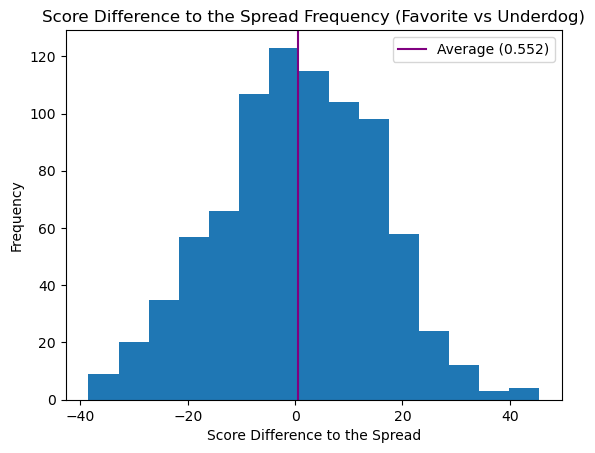

In [195]:
plt.hist(alldifference, bins=15)
plt.title('Score Difference to the Spread Frequency (Favorite vs Underdog)')
plt.xlabel('Score Difference to the Spread')
plt.ylabel('Frequency')
plt.axvline(x=alldifference.mean(), color='purple', label='Average (0.552)')
plt.legend()

We predicted a normal distribution fit. That looks about right, let's put a normal distribution curve on it

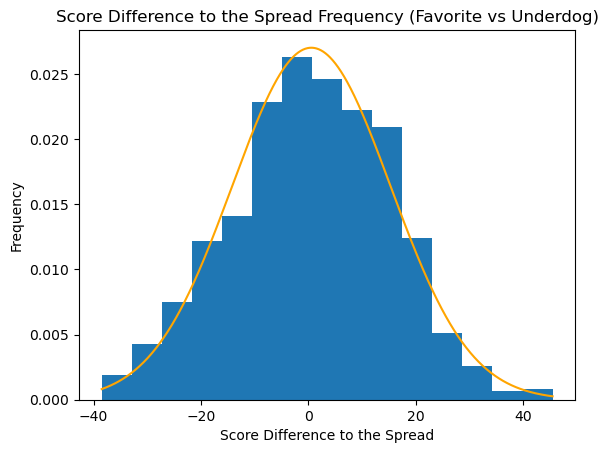

In [198]:
floatdifference = alldifference.astype(float)
mean, sd = norm.fit(floatdifference)
x = np.linspace(min(floatdifference), max(floatdifference), 1000)
normcurve = norm.pdf(x, mean, sd)

plt.hist(alldifference, bins=15, density=True)
plt.title('Score Difference to the Spread Frequency (Favorite vs Underdog)')
plt.xlabel('Score Difference to the Spread')
plt.ylabel('Frequency')
plt.plot(x, normcurve, color = 'orange')

Yep, fits a normal distribution curve! How does this compare to the other companies?

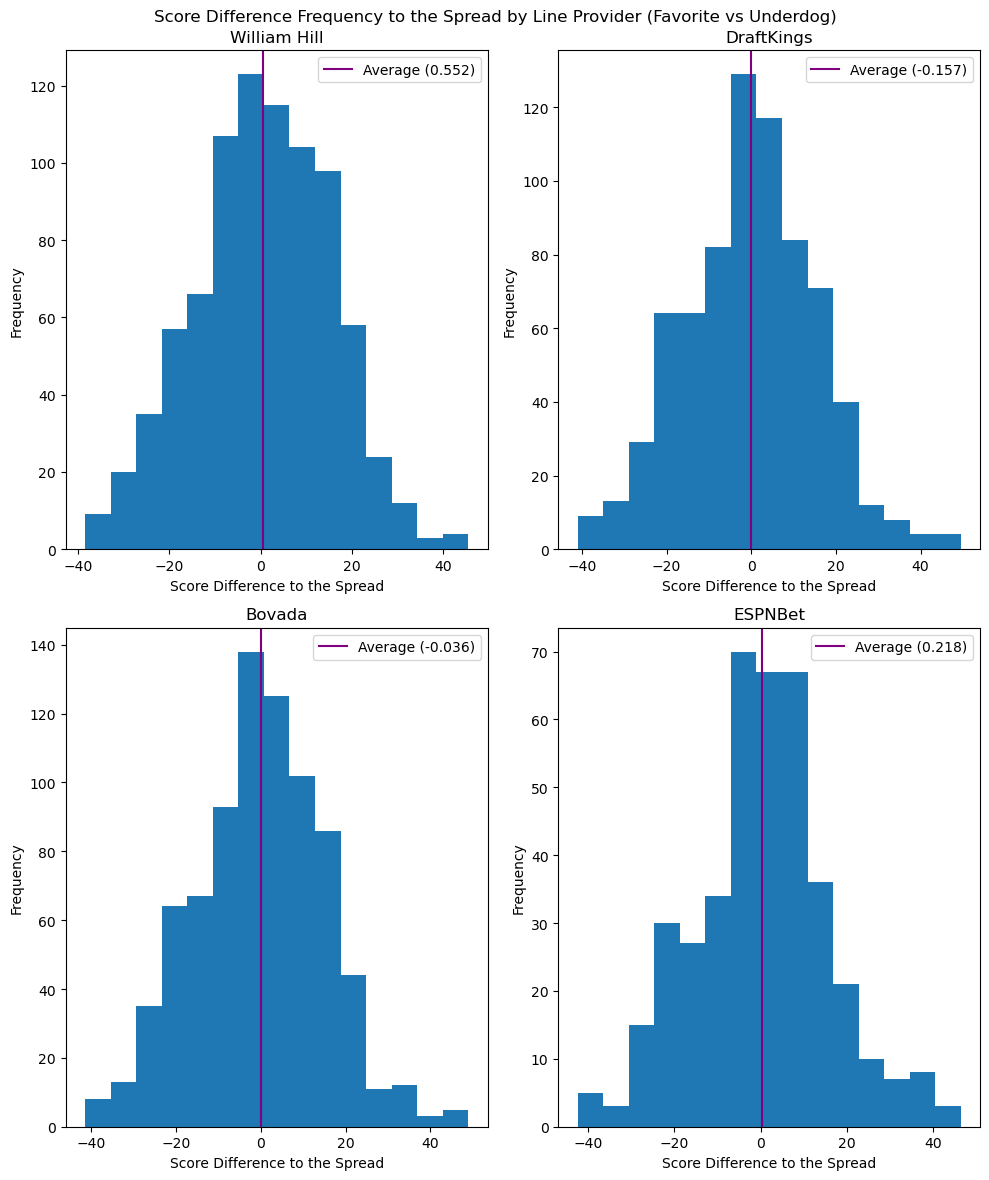

In [201]:
plt.figure(figsize=(10,12))
plt.suptitle('Score Difference Frequency to the Spread by Line Provider (Favorite vs Underdog)')


plt.subplot(2,2,1)
plt.hist(alldifference, bins=15)
plt.axvline(x=alldifference.mean(), color='purple', label='Average (0.552)')
plt.title('William Hill')
plt.xlabel('Score Difference to the Spread')
plt.ylabel('Frequency')
plt.legend()


plt.subplot(2,2,2)
plt.hist(alldifference_dk, bins=15)
plt.axvline(x=alldifference_dk.mean(), color='purple', label='Average (-0.157)')
plt.title('DraftKings')
plt.xlabel('Score Difference to the Spread')
plt.ylabel('Frequency')
plt.legend()


plt.subplot(2,2,3)
plt.hist(alldifference_bv, bins=15)
plt.axvline(x=alldifference_bv.mean(), color='purple', label='Average (-0.036)')
plt.title('Bovada')
plt.xlabel('Score Difference to the Spread')
plt.ylabel('Frequency')
plt.legend()


plt.subplot(2,2,4)
plt.hist(alldifference_eb, bins=15)
plt.axvline(x=alldifference_eb.mean(), color='purple', label='Average (0.218)')
plt.title('ESPNBet')
plt.xlabel('Score Difference to the Spread')
plt.ylabel('Frequency')
plt.legend()


plt.tight_layout()

Nice! They all look pretty similar. Makes sense that they all probably use similar methods on similar games. Maybe we can find some more unique distributions in a boxplot?

([<matplotlib.axis.YTick at 0x22a6e0c7920>,
 [Text(0, 0, 'William Hill'),
  Text(0, 1, 'DraftKings'),
  Text(0, 2, 'Bovada'),
  Text(0, 3, 'ESPNBet')])

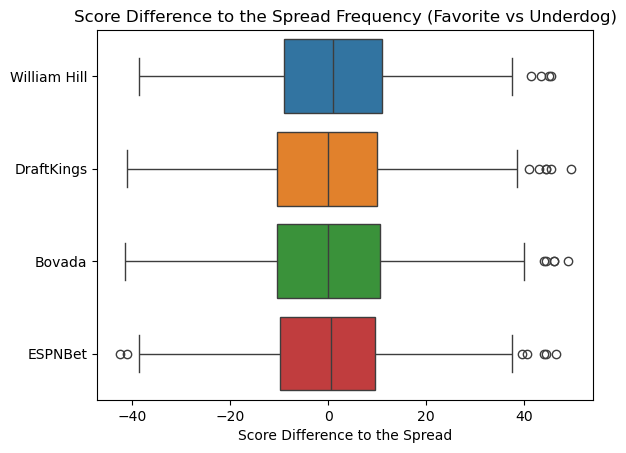

In [204]:
sns.boxplot(data = [alldifference, alldifference_dk, alldifference_bv, alldifference_eb], orient='h')
plt.title('Score Difference to the Spread Frequency (Favorite vs Underdog)')
plt.xlabel('Score Difference to the Spread')
plt.yticks([0, 1, 2, 3], ['William Hill', 'DraftKings', 'Bovada', 'ESPNBet'])

Actually, they all still look pretty similar. Some minor differences, but likely insignificant with the current data

I guess most companies are relatively consistant in their results, but we can still gather good data on how accurate they are

What about over/under? Do these also follow similar trends?

C:\Users\EP\anaconda3\Lib\site-packages\numpy\lib\histograms.py:825: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
C:\Users\EP\anaconda3\Lib\site-packages\numpy\lib\histograms.py:826: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)


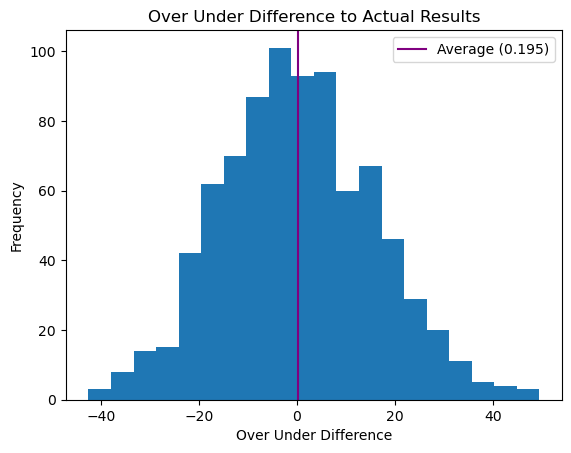

In [209]:
plt.hist(overunderdif, bins=20)
plt.axvline(x=np.nanmean(overunderdif), color='purple', label='Average (0.195)')
plt.title('Over Under Difference to Actual Results')
plt.xlabel('Over Under Difference')
plt.ylabel('Frequency')
plt.legend()

This also looks like it could also follow a standard distribution curve. Let's test it!

C:\Users\EP\anaconda3\Lib\site-packages\numpy\lib\histograms.py:825: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
C:\Users\EP\anaconda3\Lib\site-packages\numpy\lib\histograms.py:826: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)


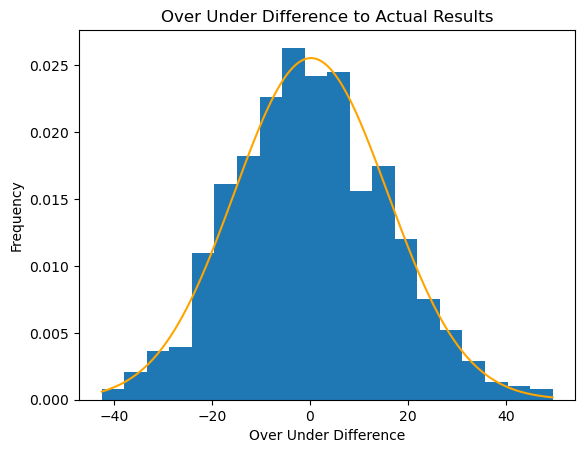

In [212]:
overunderfloat = overunderdif.astype(float)
overunderfloat = overunderfloat[np.isfinite(overunderfloat)]
ou_mean, ou_sd = norm.fit(overunderfloat)
ou_x = np.linspace(min(overunderfloat), max(overunderfloat), 1000)
ou_normcurve = norm.pdf(ou_x, ou_mean, ou_sd)

plt.hist(overunderdif, bins=20, density=True)
plt.title('Over Under Difference to Actual Results')
plt.xlabel('Over Under Difference')
plt.ylabel('Frequency')
plt.plot(ou_x, ou_normcurve, color = 'orange')

And again, I can only assume all the companies will follow a similar pattern, but let's test it to be sure

C:\Users\EP\anaconda3\Lib\site-packages\numpy\lib\histograms.py:825: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
C:\Users\EP\anaconda3\Lib\site-packages\numpy\lib\histograms.py:826: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)


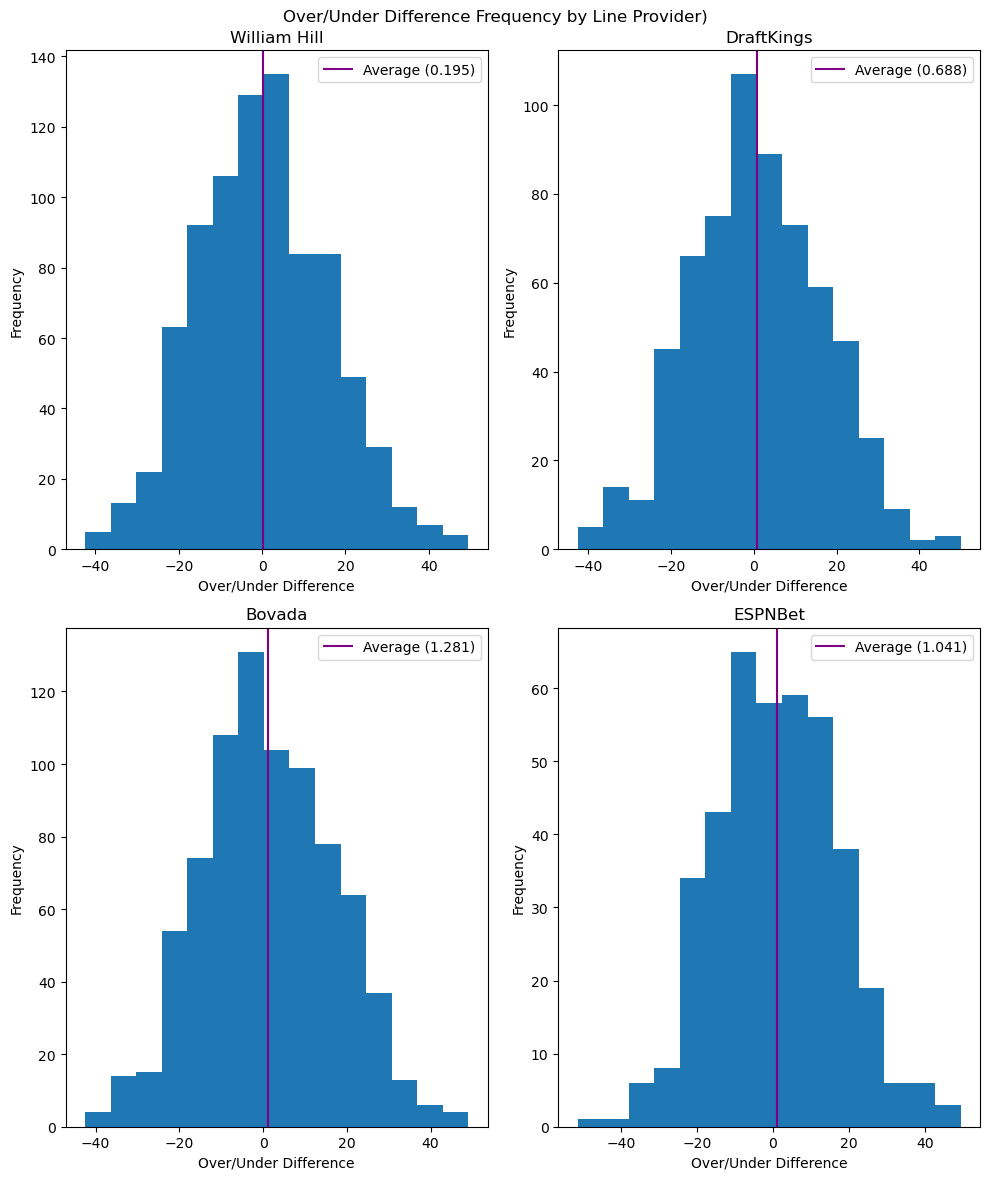

In [215]:
plt.figure(figsize=(10,12))
plt.suptitle('Over/Under Difference Frequency by Line Provider)')


plt.subplot(2,2,1)
plt.hist(overunderdif, bins=15)
plt.axvline(x=np.nanmean(overunderdif), color='purple', label='Average (0.195)')
plt.title('William Hill')
plt.xlabel('Over/Under Difference')
plt.ylabel('Frequency')
plt.legend()


plt.subplot(2,2,2)
plt.hist(overunderdif_dk, bins=15)
plt.axvline(x=np.nanmean(overunderdif_dk), color='purple', label='Average (0.688)')
plt.title('DraftKings')
plt.xlabel('Over/Under Difference')
plt.ylabel('Frequency')
plt.legend()


plt.subplot(2,2,3)
plt.hist(overunderdif_bv, bins=15)
plt.axvline(x=np.nanmean(overunderdif_bv), color='purple', label='Average (1.281)')
plt.title('Bovada')
plt.xlabel('Over/Under Difference')
plt.ylabel('Frequency')
plt.legend()


plt.subplot(2,2,4)
plt.hist(overunderdif_eb, bins=15)
plt.axvline(x=np.nanmean(overunderdif_eb), color='purple', label='Average (1.041)')
plt.title('ESPNBet')
plt.xlabel('Over/Under Difference')
plt.ylabel('Frequency')
plt.legend()


plt.tight_layout()

## Discussion and Conclusion

Some stats for reference:

In [219]:
# 'spread' mean and standard deviation

mean, sd = norm.fit(floatdifference)
print('Spread Mean:', mean)
print('Spread Standard Deviation:', sd)

# 'spread' averages from the other 3 companies

print('Alternate Spread Averages:', alldifference_dk.mean(), alldifference_bv.mean(), alldifference_eb.mean())

# 'over/under' mean and standard deviation

ou_mean, ou_sd = norm.fit(overunderfloat)
print('Over/Under Mean:', ou_mean)
print('Over/Under Standard Deviation:', ou_sd)

# 'over/under' averages from the other 3 companies

print('Alternate Over/Under Averages:', np.nanmean(overunderdif_dk), np.nanmean(overunderdif_bv), np.nanmean(overunderdif_eb))

Spread Mean: 0.5520958083832336
Spread Standard Deviation: 14.762409124275665
Alternate Spread Averages: -0.15684931506849314 -0.03598014888337469 0.21836228287841192
Over/Under Mean: 0.19484412470023982
Over/Under Standard Deviation: 15.612882364224362
Alternate Over/Under Averages: 0.6880952380952381 1.2807453416149068 1.0409429280397022


### Results Conclusion
#### **(How accurate were football betting odds from the 2023 NCAA season, and which company produces the most accurate result?)**


When determining the accuracy of betting odds, there are 2 primary types to investigate: the spread and the over/under. 

For the spread, we investigated our primary set of data with the most data (William Hill) and tested for it's difference compared to 0 (the expected 'perfect' prediction). Here, we discover that, on average, underdogs tend to outscore the spread by apporximately 0.55 points per game. Given that our standard deviation is approximately 14.76 points (approximately 2 touchdowns in either direction for either favored or unfavored teams), we can see that there is far too much varience in actual sports scores to find our average of .55 to be statistcally significant compared to 0. With a greater dataset, we can predict a tendency toward the mean, where our average would likely approach 0. With our data implying the 32% of games end more than 14 points off their prediction, the average of half a point off of zero can be deemed insignificant. Further testing with alternate companies show an average difference in projected score to actual score at appriximately -0.16, -0.04, and 0.22 points off projected outcome (negatives signifying the favorites outscoring projections). Because of this, we can find consistancy in our data, while also showing little differences despite what company distributes their betting lines. It should be noted that our data implies that sports betting companies are VERY good at creating lines that are equally likely to go either way, but are not the greatest at predicting the actual outcome of the game. This is great example of the important difference between mean and standard deviation, where the mean is incredibly accurate, but the standard deviation shows little consistancy. This answers our question: **During the 2023 NCAA season, betting odds for spreads were EXTREMELY accurate at finding an *average* score that would overestimate or underestimate almost exactly half and half, but failed to consistantly predict game scores. Furthermore, no company produced a result significant enough to dub as 'most accurate'**

For the over/under, we investigated our primary set of data with the most data (William Hill) and tested for it's difference compared to 0 (the expected 'perfect' prediction). Here, we see a mean difference in actual combined score to expected over/under at approximately 0.19 points (over the expected results since the number is positive). Similarly, when compared to the standard deviation of approximately 15.61 points, we see that 0.19 points above expected is not statistically significant enough when 32% of all games are off by about 16 points in either direction for a combined error margin of about 32 points. With such variation, we can again hypothesize tendency toward the mean with a larger data set. When compared to other companies, they all also tended to underestimate the combined score with an average of 0.69, 1.28, and 1.04 points scored over expected. These results are a bit more significant than the spreads when compared to 0, but again, it can still likely be attributed toward our large variability (even more than our spread variability). However, more data should be collected to determine if there is potentially significantly small tendency for game to go over the projected combined score, or if this is just a coincidence in the data. That being said, all companies exhibited very similar averages, displaying reliability and no significant difference amongst each other. Like the spreads, it should be noted that our data implies that sports betting companies are VERY good at creating lines that are equally likely to go either way, but are not the greatest at predicting the actual outcome of the game. This answers our question: **During the 2023 NCAA season, betting odds for over/unders were very accurate at creating a line that hits 50% of the time, but not very accurate at predicting actual outcomes. Furthermore, no company produced a result significant enough to dub as 'most accurate', although more data should be collected to determine the possibility for a miniscule bias toward underestimating game outcomes**



### Non-Data Related Discussion/Notes



I ran into very few obstacles the significantly set me back. More accurrately, I ran into smaller bugs and issues that I either self-resolved or utilized Chat-GPT to debug. Occassionally, there were functions that I forgot how to do or that we hadn't learned yet, in which case I used the references listed below, including ChatGPT. This included the normal distribution curve that took a little bit to learn and experiment with, but it taught me about the norm.fit function, which proved very informative. I also had to include a couple types of data resturcturing to make sure all my data and functions worked as they were supposed to. All in all, I'm pretty happy with my results and the method of finding and displaying my data. The only thing I would maybe change would be to gather more data outside of one singular year, since although I had a couple thousand games worth of data to work with, I feel I could get slightly more accurate/significant data from more data (as a brifly explained in my conclusion, especially for the over/under)

### References

CollegeFootballData.com. (2024). Collegefootballdata.com. https://collegefootballdata.com/




How to plot a normal distribution with Matplotlib in Python ? (2021, January 3). GeeksforGeeks. https://www.geeksforgeeks.org/how-to-plot-a-normal-distribution-with-matplotlib-in-python/



OpenAI. (2024). ChatGPT (November 2024 version) [Large language model]. https://openai.com/chatgpt


Richter, F. (2023, February 17). Infographic: America’s Sports Betting Boom. Statista Infographics. https://www.statista.com/chart/29332/gross-gaming-revenue-from-sports-betting-in-the-us/




Waskom, M. (n.d.). seaborn.boxplot — seaborn 0.11.1 documentation. Seaborn.pydata.org. https://seaborn.pydata.org/generated/seaborn.boxplot.html
‌
